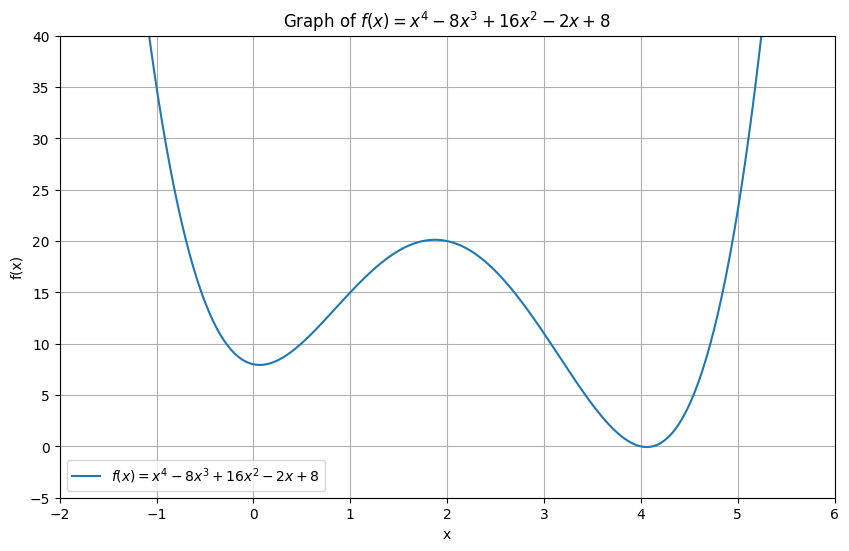

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 定義函數 f(x)
def f(x):
    return x**4 - 8*x**3 + 16*x**2 - 2*x + 8

# 生成 x 值的範圍
x = np.linspace(-2, 6, 400)

# 計算對應的 y 值
y = f(x)

# 繪製圖形
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=r'$f(x) = x^4 - 8x^3 + 16x^2 - 2x + 8$')
plt.title('Graph of $f(x) = x^4 - 8x^3 + 16x^2 - 2x + 8$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.xlim(-2, 6)
plt.ylim(-5, 40)   
plt.grid(True)
plt.legend()
plt.show()

In [20]:
#use scipy to generate N smaples from a normal distribution with mean 0 and standard deviation 1
import scipy.stats as stats

N = 1000
mu = 0
sigma = 1
x = stats.norm.rvs(loc = mu, scale = sigma, size = N)

#compute the joint likelihood of N samples from a normal distribution with mean u and standard deviation 1
mu = np.linspace(-1, 1, 1000)
sigma = 1
L= np.zero(len(mu))
for i in range(len(mu)):
    L[i] = np.prod(stats.norm.pdf(x, loc = mu[i], scale = sigma))

#plot the likelihood function
plt.figure(figsize=(10, 6))
plt.plot(mu, L)
plt.title('Likelihood function')
plt.xlabel('u')
plt.ylabel('L(u)')
plt.xlim(-1, 1)
plt.ylim(0, 0.5)
plt.grid(True)
plt.show()



#L=stats.norm.pdf(x, loc = mu, scale = sigma)
mu = 0
sigma = 1
L = lambda u : stats.norm.pdf(x[0], loc=u, scale=sigma)
u = np.linspace(-5, 5, 100)
plt.figure(figsize=(10, 6))
plt.plot(u, L(u))
plt.title('PDF of a normal distribution')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.xlim(-5, 5)
plt.ylim(0, 0.5)
plt.grid(True)
plt.show()





AttributeError: module 'numpy' has no attribute 'zero'

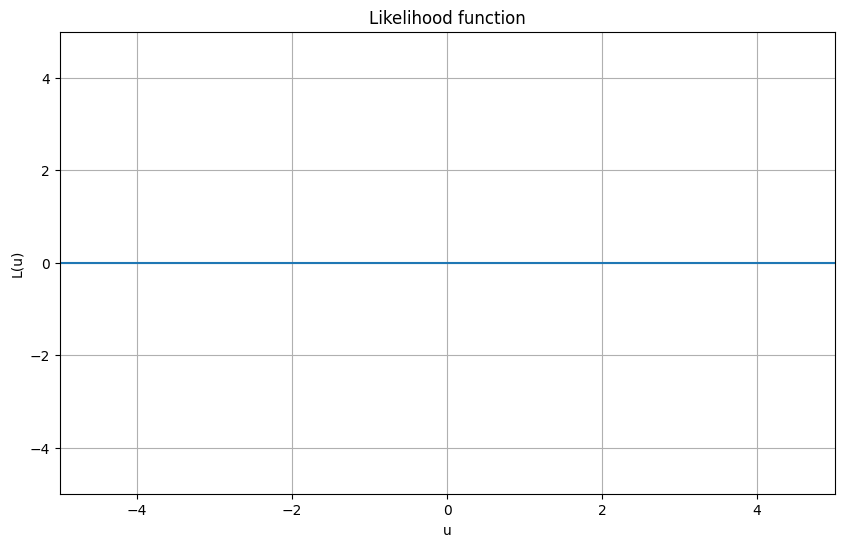

In [28]:
#use scipy to generate N smaples from a normal distribution with mean 0 and standard deviation 1
import numpy as np
import scipy.stats as stats

N = 100
mu = 0
sigma = 1
x = stats.norm.rvs(loc = mu, scale = sigma, size = N)

#compute the joint likelihood of N samples from a normal distribution with mean u and standard deviation 1
mu = np.linspace(-5, 5, 1000)
sigma = 1
L= np.zeros(len(mu))
for i in range(len(mu)):
    L[i] = np.prod(stats.norm.pdf(x, loc = mu[i], scale = sigma))

#plot the likelihood function
plt.figure(figsize=(10, 6))
plt.plot(mu, L)
plt.title('Likelihood function')
plt.xlabel('u')
plt.ylabel('L(u)')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid(True)
plt.show()

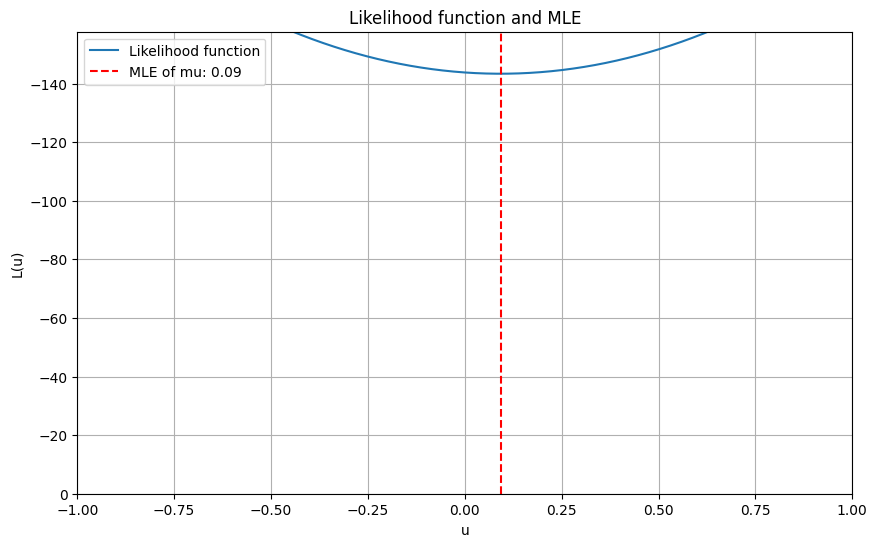

Maximum Likelihood Estimate of mu: 0.09


In [38]:
# 使用 scipy 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

N = 100
mu_true = 0
sigma_true = 1
x = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 計算 N 個樣本的聯合似然函數，假設均值為 u，標準差為 1
mu = np.linspace(-1, 1, 1000)
sigma = 1
L = np.zeros(len(mu))   #在記憶體先抓一個空間出來
for i in range(len(mu)):
     #L[i]=np.sum(np.log(stats.norm.pdf(x, loc=mu[i], scale=sigma)))
    L[i] = np.prod(stats.norm.pdf(x, loc=mu[i], scale=sigma))
    

# 找到最大概似估計的均值
mle_mu = mu[np.argmax(L)]

# 繪製聯合似然函數圖形
plt.figure(figsize=(10, 6))
plt.plot(mu, L, label='Likelihood function')
plt.axvline(mle_mu, color='r', linestyle='--', label=f'MLE of mu: {mle_mu:.2f}')
plt.title('Likelihood function and MLE')
plt.xlabel('u')
plt.ylabel('L(u)')
plt.xlim(-1, 1)
plt.ylim(0, np.max(L) * 1.1)
plt.grid(True)
plt.legend()
plt.show()

print(f'Maximum Likelihood Estimate of mu: {mle_mu:.2f}')

-0.1511511511511512 -147.0607464040314


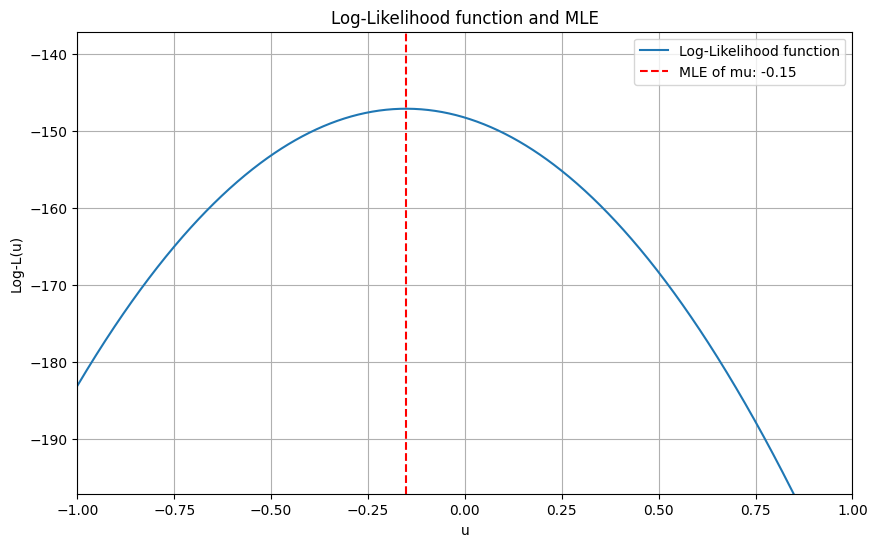

Maximum Likelihood Estimate of mu: -0.15


In [58]:
# 使用 scipy 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

N = 100
mu_true = 0
sigma_true = 1
x = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 計算 N 個樣本的對數聯合似然函數，假設均值為 u，標準差為 1
mu = np.linspace(-1, 1, 1000)
sigma = 1
L = np.zeros(len(mu))   # 在記憶體先抓一個空間出來
for i in range(len(mu)):
    L[i] = np.sum(np.log(stats.norm.pdf(x, loc=mu[i], scale=sigma)))

# 找到最大對數概似估計的均值
mle_mu = mu[np.argmax(L)]
print(mle_mu, np.max(L))

# 繪製對數聯合似然函數圖形
plt.figure(figsize=(10, 6))
plt.plot(mu, L, label='Log-Likelihood function')
plt.axvline(mle_mu, color='r', linestyle='--', label=f'MLE of mu: {mle_mu:.2f}')
plt.title('Log-Likelihood function and MLE')
plt.xlabel('u')
plt.ylabel('Log-L(u)')
plt.xlim(-1, 1)
plt.ylim(np.max(L) - 50, np.max(L) + 10)
plt.grid(True)
plt.legend()
plt.show()

print(f'Maximum Likelihood Estimate of mu: {mle_mu:.2f}')

In [59]:
#寫一支副程式，計算對數聯合似然函數
import numpy as np
import scipy.stats as stats

def log_likelihood(x, mu, sigma):
    return np.sum(np.log(stats.norm.pdf(x, loc=mu, scale=sigma)))


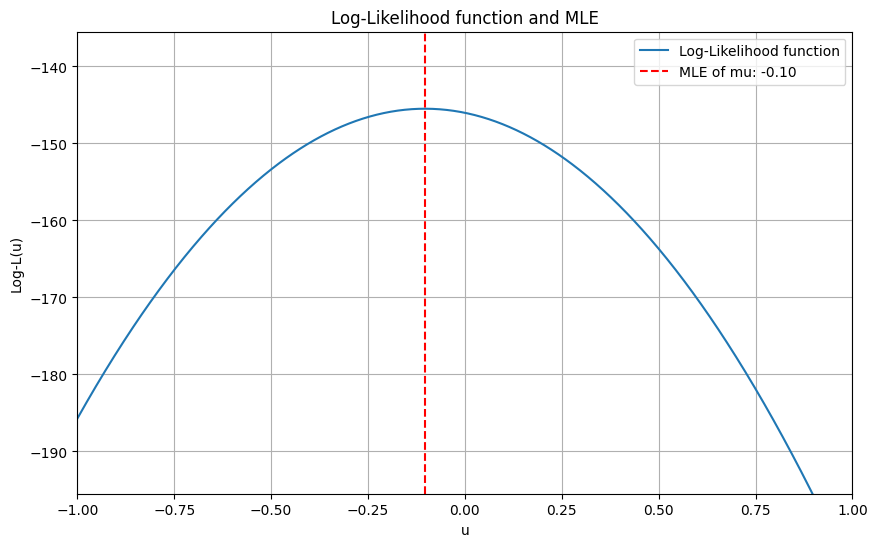

In [62]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

N = 100
mu_true = 0
sigma_true = 1
x = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
mu = np.linspace(-1, 1, 1000)
sigma = 1
L = np.zeros(len(mu))   #在記憶體先抓一個空間出來
for i in range(len(mu)):
     #L[i]=np.sum(np.log(stats.norm.pdf(x, loc=mu[i], scale=sigma)))
    L[i] = log_likelihood(x, mu[i], sigma)  

# 找到最大概似估計的均值    
mle_mu = mu[np.argmax(L)]

# 繪製對數聯合似然函數圖形
plt.figure(figsize=(10, 6))
plt.plot(mu, L, label='Log-Likelihood function')
plt.axvline(mle_mu, color='r', linestyle='--', label=f'MLE of mu: {mle_mu:.2f}')
plt.title('Log-Likelihood function and MLE')
plt.xlabel('u')
plt.ylabel('Log-L(u)')
plt.xlim(-1, 1)
plt.ylim(np.max(L) - 50, np.max(L) + 10)
plt.grid(True)
plt.legend()
plt.show()

In [70]:
#利用演算法計算最大概似估計
from scipy.optimize import minimize

# 定義對數似然函數的負數
def neg_log_likelihood(mu):
    return -log_likelihood(x, mu, sigma)
   
# 使用 minimize 函數計算最大概似估計
result = minimize(neg_log_likelihood, 0)
mle_mu = result.x[0]
print("mle_mu:", mle_mu)    

mle_mu: -0.10305648634812233
